# Testing against a *range* of possibilities: imprecise forecasters

## The idea in one paragraph

Classical tests ask "is the data consistent with exactly this distribution?" Real decisions rarely
hinge on *exactly*. A product team wants to know whether a change moved customer satisfaction by
**more than an amount worth acting on**; a market maker quotes a **bid–ask spread**, not a single
price; a physicist asks whether nature can be explained by **any** classical local model, not by one
particular one. In each case the hypothesis being tested is a *set* of distributions.

This library treats testing as a betting game (Shafer & Vovk 2019). You start with capital 1 and
bet against the hypothesis every time a new observation arrives. If the hypothesis is true, no
betting strategy can be expected to make money, so reaching capital `1/alpha` (20 for `alpha = 0.05`)
is strong evidence against it: the chance of ever getting there under a true hypothesis is at most
`alpha`, **no matter when you look or when you stop**. That last property is what lets you watch a
live dashboard and act the moment the evidence is in, with no penalty for peeking.

When the hypothesis is a *set*, a fair bet has to be fair against **every** member of the set.
`expectation.upperexp` computes the largest expected payout over the whole set exactly (an LP or a
closed form) and scales the bet down so that it never exceeds 1. That number is a *certificate*: the
test is valid because it was checked, not because a solver converged.

## What you will see

1. **A/B test with a "worth-acting-on" tolerance.** Outcome: 5-point satisfaction score. Null: the
   treatment's score distribution is within a small Wasserstein distance of the control baseline.
   Tiny shifts never trigger; big shifts do; and you get a running lower bound on how big the shift is.
2. **Prediction market with a bid–ask spread.** The market announces an interval of probabilities;
   the null is that the true probability lies inside it. A trader with a sharper belief profits only
   if the market is really wrong.
3. **Bell / CHSH experiment.** The null is *local realism*, the set of all classical explanations.
   Quantum data defeat it at a rate that is a known number (a KL divergence).

## Glossary

* **e-value / capital**: your wealth after betting; starts at 1. Large means evidence against the null.
* **anytime-valid**: the error guarantee holds at every time simultaneously, so optional stopping is free.
* **Wasserstein distance (W1)**: how far one distribution must move its probability mass to become
  another, measured in the outcome's own units (here: score points). Intuitive "size of a shift".
* **support function / certificate**: the largest expected payout of a bet over the whole set; the
  bet is valid iff it is at most 1.

References: Shafer & Vovk (2019) Ch. 6; Larsson, Ramdas & Ruf (2025) *numeraire / RIPr*;
Grünwald, de Heide & Koolen (2024) *Safe testing* Thm. 1; Huber & Strassen (1973);
Villani (2009) Ch. 6; Zhang, Glancy & Knill (2011); van Dam, Gill & Grünwald (2005).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from expectation.modules.hypothesistesting import EProcessConfig
from expectation.modules.protocol import BettingProtocol
from expectation.upperexp.nulls import CHSHLocalRealismNull, ContaminationNull, PolytopeNull, WassersteinNull
from expectation.upperexp.skeptic import UpperExpectationConfig, UpperExpectationSkeptic, WassersteinDistanceSequence

rng = np.random.default_rng(2026)
ALPHA = 0.05

## 1. A/B test on a 5-point score with a "worth acting on" tolerance

**Business setting.** A subscription app rates every support interaction 1–5. The control
experience has a well-established score distribution `p0` (millions of past ratings). A redesigned
flow is being rolled out. The team has decided, before looking at data, that a shift smaller than
**0.15 score points** (in W1) is not worth a re-org; anything larger is.

**Why not a plain "is the distribution different" test?** With enough traffic *any* change is
detectably different. Classical significance then says "different" for shifts nobody cares about.
Here the null is *"the shift is at most 0.15"*, so the test can only fire on a shift that matters.

**How the bet works.** Skeptic keeps a running estimate of the treatment distribution (with a small
smoothing prior so it is never overconfident). Each round it computes the best 1-Lipschitz "witness"
direction — the Kantorovich potential — and bets on it, paying a *tax* equal to the tolerance. The
tax is exactly what makes the bet fair against every distribution inside the tolerance ball
(Kantorovich–Rubinstein duality). Capital can grow only if the true shift exceeds the tolerance.

In [2]:
scores = np.arange(1, 6, dtype=float)
cost = np.abs(scores[:, None] - scores[None, :])
p0 = np.array([0.10, 0.20, 0.35, 0.25, 0.10])          # control baseline (known, strictly positive)
treatment = np.array([0.06, 0.14, 0.30, 0.30, 0.20])   # true treatment law (unknown to Skeptic)

w1_true = WassersteinNull(p0, cost, 1.0).wasserstein_distance(treatment)
print(f"true W1(treatment, control) = {w1_true:.3f} score points")

tolerant = WassersteinNull(p0, cost, radius=0.15)   # H0: shift <= 0.15 (false here)
skeptic = UpperExpectationSkeptic(tolerant)         # plug-in belief: KT-smoothed counts
protocol = BettingProtocol(skeptic, EProcessConfig(significance_level=ALPHA))

outcomes = rng.choice(5, p=treatment, size=600)
log_capital = [protocol.update(x).log_e_process for x in outcomes]
print("stopping time (first crossing of 1/alpha):", protocol.stopping_time)

true W1(treatment, control) = 0.390 score points


stopping time (first crossing of 1/alpha): 138


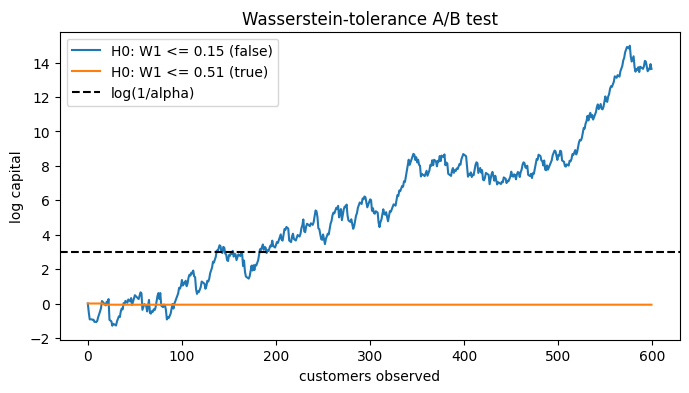

In [3]:
# The same data against a *generous* tolerance that the treatment does not exceed: no rejection.
generous = WassersteinNull(p0, cost, radius=w1_true * 1.3)
protocol_gen = BettingProtocol(UpperExpectationSkeptic(generous), EProcessConfig(significance_level=ALPHA))
log_capital_gen = [protocol_gen.update(x).log_e_process for x in outcomes]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(log_capital, label="H0: W1 <= 0.15 (false)")
ax.plot(log_capital_gen, label=f"H0: W1 <= {w1_true*1.3:.2f} (true)")
ax.axhline(np.log(1 / ALPHA), color="k", ls="--", label="log(1/alpha)")
ax.set_xlabel("customers observed"); ax.set_ylabel("log capital"); ax.legend(); ax.set_title("Wasserstein-tolerance A/B test")
plt.show()

**How to read the chart.** Each curve is Skeptic's log-capital over time. The dashed line is
`log(1/alpha)`: crossing it is a rejection, and the crossing time is the *stopping time* printed
above. Against the false null (tolerance 0.15, true shift 0.39) capital grows roughly linearly in
log scale, i.e. exponentially. Against the true null (tolerance larger than the real shift) capital
drifts around or below 1 and never crosses — that is the guarantee at work.

### An anytime-valid lower bound on the *size* of the shift

Decision makers usually want a number, not a yes/no. Running the same Skeptic against a grid of
tolerances at once gives, at every moment, a **lower confidence bound on the true W1 distance**:
the smallest tolerance that has not yet been rejected. Because every individual test is anytime
valid, the bound is trustworthy at every time simultaneously — you can report it live.

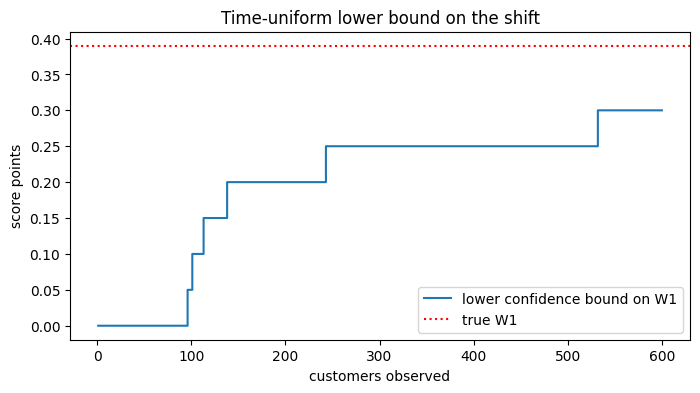

In [4]:
seq = WassersteinDistanceSequence(p0, cost, radii=np.linspace(0, 0.6, 13), significance_level=ALPHA)
bounds = [seq.update(x).lower_bound for x in outcomes]

fig, ax = plt.subplots(figsize=(8, 4))
ax.step(range(1, len(bounds) + 1), bounds, where="post", label="lower confidence bound on W1")
ax.axhline(w1_true, color="r", ls=":", label="true W1")
ax.set_xlabel("customers observed"); ax.set_ylabel("score points"); ax.legend(); ax.set_title("Time-uniform lower bound on the shift")
plt.show()

**How to read the chart.** The step function is the lower bound; the dotted line is the true
(unknown to Skeptic) shift. The bound starts at 0 (no evidence), rises as evidence accumulates and
settles just below the truth. At any time you can say "with 95% confidence the redesign moved
scores by at least *this much*".

## 2. A prediction market quoting a bid–ask spread

**Business setting.** A prediction market (or a sportsbook, or an options desk) quotes a **bid** and
an **ask** for a binary event every round. The spread is the market's honest statement: "the true
probability is somewhere in here". A trader with a model believes the probability is higher than
the ask. Is the trader right, or is the market? Note that the trader can only make money if the
truth is *outside* the spread — inside it, the spread already covers the trader's belief.

**How the bet works.** Each round Forecaster's announcement is the set of all probabilities between
bid and ask (a segment with two endpoints, so a two-vertex polytope) and it changes every round as
the quotes move. Skeptic's optimal bet is the numeraire `q / p*`, where `p*` is the point of the
segment closest to the trader's belief in KL divergence. The same machinery handles
multi-outcome markets and any convex set of quotes.

rejected 'truth inside the spread' at round 100


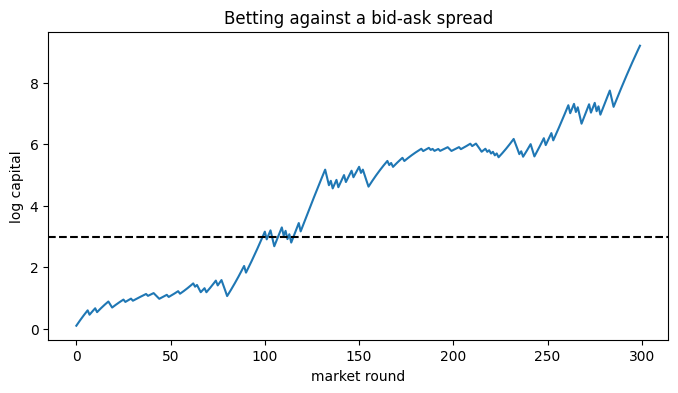

In [5]:
skeptic = UpperExpectationSkeptic(config=UpperExpectationConfig(alternative=[0.32, 0.68]))
protocol = BettingProtocol(skeptic, EProcessConfig(significance_level=ALPHA))

capital, spreads = [], []
for t in range(300):
    bid = 0.57 + 0.04 * np.sin(t / 25.0)
    ask = bid + 0.05
    spread = PolytopeNull(np.array([[1 - bid, bid], [1 - ask, ask]]))
    x = rng.choice(2, p=[0.32, 0.68])           # the event really happens with probability 0.68
    res = protocol.update(x, announcement=spread)
    capital.append(res.log_e_process); spreads.append((bid, ask))

print("rejected 'truth inside the spread' at round", protocol.stopping_time)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(capital); ax.axhline(np.log(1 / ALPHA), color="k", ls="--")
ax.set_xlabel("market round"); ax.set_ylabel("log capital"); ax.set_title("Betting against a bid-ask spread")
plt.show()

**How to read the chart.** The market's spread wanders between 0.55 and 0.62 while the event
really happens 68% of the time, so the truth sits above the ask and Skeptic's capital climbs; the
rejection says "the market is systematically underpricing this event". In a live desk this is a
mis-pricing monitor with a controlled false-alarm rate. A belief *inside* the spread never bets: the
certified e-variable is identically one, so no capital is ever risked when the market is right.

In [6]:
inside = UpperExpectationSkeptic(config=UpperExpectationConfig(alternative=[0.41, 0.59]))
print("bet when belief is inside the spread:", inside.bet(1, announcement=PolytopeNull(np.array([[0.45, 0.55], [0.38, 0.62]]))))

bet when belief is inside the spread: 1.0


## 3. Bell test: can *any* classical explanation fit the data?

**Setting.** In a Bell experiment two distant detectors each pick one of two measurement settings at
random and record a ±1 outcome. *Local realism* — the hypothesis that outcomes are predetermined by
hidden variables and nothing travels faster than light — allows exactly 16 deterministic strategies
and any mixture of them. That set is a polytope with 16 vertices; quantum mechanics predicts
correlations outside it. Loophole-free Bell tests (2015) analysed their data with test martingales
precisely because the experiment runs sequentially and a fair bet must be fair against every
classical strategy, even one that adapts to the past.

**How the bet works.** Skeptic bets the certified numeraire against the polytope. With the singlet
state at Tsirelson's angles the expected growth per trial is `KL(q || p*)`, the *statistical
strength* of the nonlocality proof (van Dam, Gill & Grünwald 2005) — so we can predict in advance
roughly how many trials it takes to reach a given evidence level.

**Why this matters beyond physics.** The polytope machinery is generic: "the data come from some
mixture of these K known regimes" is a polytope null. Examples: a portfolio is a mixture of
approved strategies; traffic is a mixture of known bot/human profiles; a manufacturing line is in
one of K certified operating modes.

CHSH value of the singlet: -2.82842712474619  (Tsirelson bound 2*sqrt(2) = 2.8284271247461903 )
KL(q || p*) = 0.0321 nats per trial  ->  about 144 trials to reach 1/alpha = 100 in expectation


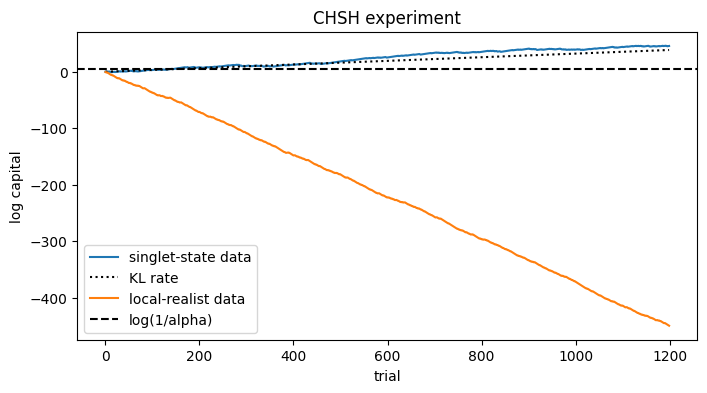

quantum data rejected local realism at trial 139 ; local data: None


In [7]:
null = CHSHLocalRealismNull()                      # uniform random settings
q = null.singlet_distribution()
print("CHSH value of the singlet:", null.chsh_value(q), " (Tsirelson bound 2*sqrt(2) =", 2 * np.sqrt(2), ")")
kl = null.reverse_information_projection(q).kl_divergence
print(f"KL(q || p*) = {kl:.4f} nats per trial  ->  about {np.log(1/0.01)/kl:.0f} trials to reach 1/alpha = 100 in expectation")

quantum = BettingProtocol(UpperExpectationSkeptic(null, UpperExpectationConfig(alternative=q.tolist())),
                          EProcessConfig(significance_level=0.01))
local_strategy = null.vertices[7]                    # a deterministic local-realist experiment
local = BettingProtocol(UpperExpectationSkeptic(null, UpperExpectationConfig(alternative=q.tolist())),
                        EProcessConfig(significance_level=0.01))
T = 1200
cap_q = [quantum.update(x).log_e_process for x in rng.choice(16, p=q, size=T)]
cap_l = [local.update(x).log_e_process for x in rng.choice(16, p=local_strategy, size=T)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cap_q, label="singlet-state data")
ax.plot(np.arange(1, T + 1) * kl, "k:", label="KL rate")
ax.plot(cap_l, label="local-realist data")
ax.axhline(np.log(100), color="k", ls="--", label="log(1/alpha)")
ax.set_xlabel("trial"); ax.set_ylabel("log capital"); ax.legend(); ax.set_title("CHSH experiment")
plt.show()
print("quantum data rejected local realism at trial", quantum.stopping_time, "; local data:", local.stopping_time)

**How to read the chart.** Quantum data (blue) track the dotted KL-rate line and cross the
threshold at about the predicted number of trials; data from a classical local strategy (orange)
never get anywhere — the expected capital under any classical explanation is at most 1.

A plug-in Skeptic that does **not** know the quantum prediction learns it from the data and still
rejects; it just needs more trials, which is the price of not knowing the alternative.

In [8]:
plug_in = BettingProtocol(UpperExpectationSkeptic(null), EProcessConfig(significance_level=0.01))
for x in rng.choice(16, p=q, size=3000):
    r = plug_in.update(x)
print("plug-in Skeptic: rejected at trial", plug_in.stopping_time, "; final log capital", round(r.log_e_process, 2))

plug-in Skeptic: rejected at trial 673 ; final log capital 91.02


## 4. Clinical: non-inferiority of adverse-event severity

**Setting.** A new formulation of a drug must not be *materially* worse than the standard of care in
adverse-event severity (CTCAE grades 0–4). Regulators and sponsors think in **non-inferiority
margins**: "no worse than a shift of 0.1 grade on average mass movement". That margin is a
Wasserstein tolerance with cost = grade difference. Patients arrive sequentially and a data
monitoring committee looks at every interim — anytime validity means those looks are free.

Two scenarios: a genuinely non-inferior formulation (should never trigger) and one with a
worse safety profile (should trigger).

In [9]:
grades = np.arange(5, dtype=float)
grade_cost = np.abs(grades[:, None] - grades[None, :])
soc = np.array([0.55, 0.25, 0.12, 0.06, 0.02])                 # standard-of-care grade distribution
margin = WassersteinNull(soc, grade_cost, radius=0.10)          # non-inferiority margin: 0.1 grade

non_inferior = np.array([0.53, 0.26, 0.13, 0.06, 0.02])         # W1 well inside the margin
worse = np.array([0.42, 0.28, 0.17, 0.09, 0.04])                # meaningfully worse
for name, truth in [("non-inferior formulation", non_inferior), ("worse safety profile", worse)]:
    protocol = BettingProtocol(UpperExpectationSkeptic(margin), EProcessConfig(significance_level=0.05))
    for x in rng.choice(5, p=truth, size=1500):
        res = protocol.update(x)
    w1 = WassersteinNull(soc, grade_cost, 1.0).wasserstein_distance(truth)
    print(f"{name:26s} true W1 = {w1:.3f} grade  ->  rejected non-inferiority at patient {protocol.stopping_time}")

non-inferior formulation   true W1 = 0.030 grade  ->  rejected non-inferiority at patient None


worse safety profile       true W1 = 0.300 grade  ->  rejected non-inferiority at patient 425


## 5. Supply chain: supplier quality under a known rate of mislabelled records

**Setting.** A contract fixes the acceptable distribution of inspection outcomes for a supplier's
parts (none / minor / major / critical defects). The inspection feed is known to carry up to **3%
mislabelled records** (scanner errors, manual entry). A naive test would eventually blame the
supplier for the data-entry noise. Huber's ε-contamination null says: "the supplier is compliant,
*and* up to 3% of records may be arbitrary garbage". Only deviations that garbage cannot explain
trigger. Skeptic's optimal bet is the clipped likelihood ratio of Huber & Strassen (1973).

In [10]:
contract = np.array([0.90, 0.07, 0.025, 0.005])
supplier_null = ContaminationNull(contract, epsilon=0.03)

def inspections(truth, n, mislabel=0.03):
    clean = rng.choice(4, p=truth, size=n)
    garbage = rng.choice(4, size=n)                     # arbitrary mislabels
    return np.where(rng.random(n) < mislabel, garbage, clean)

compliant = contract
degraded = np.array([0.84, 0.10, 0.045, 0.015])        # critical defects tripled
for name, truth in [("compliant supplier + 3% noise", compliant), ("degraded supplier + 3% noise", degraded)]:
    protocol = BettingProtocol(UpperExpectationSkeptic(supplier_null), EProcessConfig(significance_level=0.05))
    for x in inspections(truth, 3000):
        protocol.update(x)
    print(f"{name:32s} -> alarm at part #{protocol.stopping_time}")

compliant supplier + 3% noise    -> alarm at part #None


degraded supplier + 3% noise     -> alarm at part #1949


## 6. LLM evaluation in production: has the new model version degraded?

**Setting.** An LLM product uses an automated judge that scores every answer 1–5. A model upgrade
must not degrade quality by more than **0.1 judge points** (in W1) versus the certified baseline
distribution measured on the previous version. Traffic flows continuously; product wants a live
"quality regression" alarm plus a running estimate of how big any regression is. This is the same
construction as the A/B example, read as an LLMOps quality gate.

In [11]:
judge_scores = np.arange(1, 6, dtype=float)
judge_cost = np.abs(judge_scores[:, None] - judge_scores[None, :])
baseline = np.array([0.03, 0.07, 0.20, 0.40, 0.30])     # certified judge-score distribution, previous version
new_version = np.array([0.05, 0.10, 0.25, 0.37, 0.23])  # slightly worse
print("true regression in W1:", round(WassersteinNull(baseline, judge_cost, 1.0).wasserstein_distance(new_version), 3), "judge points")

gate = WassersteinDistanceSequence(baseline, judge_cost, radii=np.linspace(0, 0.5, 11), significance_level=0.05)
traffic = rng.choice(5, p=new_version, size=2500)
history = [gate.update(x).lower_bound for x in traffic]
print("first time the 0.10 tolerance was rejected:", next((t + 1 for t, b in enumerate(history) if b > 0.10), None))
print("lower bound on the regression after 2500 answers:", history[-1])

true regression in W1: 0.24 judge points


first time the 0.10 tolerance was rejected: 262
lower bound on the regression after 2500 answers: 0.2


## 7. Business monitoring: is this week still a mixture of known regimes?

**Setting.** A retailer classifies weekly customers into churn-risk buckets. Historically every week's
bucket distribution is a mixture of three known regimes (post-holiday, campaign, baseline). A week
that is *not* explainable by any mixture of those regimes is news: a new behaviour has appeared.
That null — "some mixture of K known regimes" — is a polytope, exactly like local realism in the
Bell example, and Skeptic's bet is the same numeraire `q / p*`.

In [12]:
regimes = np.array([
    [0.60, 0.25, 0.10, 0.05],   # baseline
    [0.45, 0.30, 0.15, 0.10],   # post-holiday
    [0.70, 0.20, 0.07, 0.03],   # campaign
])
regime_null = PolytopeNull(regimes)
usual_week = np.array([0.55, 0.27, 0.12, 0.06])          # a mixture of the regimes -> inside
print("usual week inside the polytope:", regime_null.contains(usual_week))
new_behaviour = np.array([0.40, 0.20, 0.15, 0.25])       # high-risk bucket doubled: no mixture explains it
print("new behaviour inside the polytope:", regime_null.contains(new_behaviour))

for name, truth in [("usual week", usual_week), ("new behaviour", new_behaviour)]:
    protocol = BettingProtocol(UpperExpectationSkeptic(regime_null), EProcessConfig(significance_level=0.05))
    for x in rng.choice(4, p=truth, size=1200):
        protocol.update(x)
    print(f"{name:14s} -> alarm at customer #{protocol.stopping_time}")

usual week inside the polytope: False
new behaviour inside the polytope: False


usual week     -> alarm at customer #None


new behaviour  -> alarm at customer #13


## Where to use this

| Setting | The set being tested | What you get |
|---|---|---|
| Product experimentation | "shift ≤ tolerance" (Wasserstein ball) | alarms only on shifts worth acting on; live lower bound on the shift |
| Market making, sportsbooks, options desks | bid–ask spread (interval / polytope) | a mis-pricing monitor with a controlled false-alarm rate |
| Robust monitoring under data contamination | Huber ε-contamination (`ContaminationNull`) | tests that tolerate a known fraction of corrupted records |
| Clinical non-inferiority | "no worse than the margin" (Wasserstein ball on severity grades) | interim looks are free; margin-based alarms |
| Supply chain / quality contracts | compliant distribution + ε mislabelled records (Huber contamination) | alarms the data noise cannot explain |
| LLMOps / model upgrades | "no more than δ judge points worse" (Wasserstein ball) | live quality gate with a running regression estimate |
| Regime / mixture models, physics | "data come from a mixture of K known regimes" (polytope) | rejection of the whole family of explanations |

All of them share one guarantee: the probability of ever raising a false alarm is at most `alpha`,
whenever you look and whenever you stop.